In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')


In [3]:
img_name = 'HAND1_Brachyury_mid_+'
channel_names = ['HAND1', 'BMP4', 'T', 'Hoechst']

cell_df = pd.read_csv(f'../data/training/{img_name}.csv', index_col=0)
print(cell_df.shape)
cell_df.head(3)


(99489, 18)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,orientation,equivalent_diameter,circularity,aspect_ratio,HAND1_mean,BMP4_mean,T_mean,Hoechst_mean
cell_id,,,,,,,,,,,,,,,,,,
1,10.848039,435.923203,612.0,98.662951,96.416209,0.800231,0.948837,0.809524,36.529343,21.906354,1.480949,27.914559,0.827296,1.667523,171.890523,114.013072,203.991830,479.598039
2,10.825397,3754.952381,315.0,69.213203,68.299749,0.641427,0.934718,0.753589,23.400506,17.952500,-0.493996,20.026744,0.848559,1.303468,190.577778,113.365079,177.511111,582.238095
3,7.522222,5936.959259,270.0,64.142136,63.492075,0.825511,0.954064,0.838509,25.049870,14.137784,1.433873,18.541162,0.841656,1.771839,187.370370,112.544444,196.588889,585.100000


## Non-cell-autonomous model: neighbors' features -> a cell's own features

Complement to `intrinsic.ipynb`: instead of predicting a cell's own feature from its own
OTHER features, predict it from its NEIGHBORS' features. `NeighborFeaturePredictor`
(`tools/gnn.py`) never sees the center cell's own features, only its neighbors' -- combined
via a learned distance decay (closer neighbors matter more; see `DistanceAttentionConv`).

Which columns are the neighbor inputs and which are the target is fully configurable in the
`EXPERIMENTS` cell below -- e.g. neighbors' morphology -> own IF, neighbors' IF -> own
morphology, or same-modality versions (neighbors' morphology -> own morphology, neighbors'
IF -> own IF, testing spatial autocorrelation/clustering of a single modality).


In [ ]:
from torch_geometric.data import Data

from tools.morphology import (
    MORPHOLOGY_COLS,
    marker_cols,
    zero_out_negative_if,
    knn_edge_index,
    NeighborFeaturePredictor,
    set_seed,
    leave_one_out_configs,
    make_scaler,
    split_indices,
    indices_to_mask,
    train_gnn,
    plot_loss_curves,
    plot_pred_vs_actual,
    r2_table,
    plot_feature_importance_by_target,
    plot_experiment_comparison,
    plot_spatial_cross_correlation,
    top_correlated_pairs,
    permutation_importance_gnn,
)

SEED = 0
set_seed(SEED)

EXCLUDE_HOECHST = True
# If True, sets `{marker}_mean` to 0 for every cell where `{marker}+` is False --
# treats IF-negative as true zero signal rather than whatever background/baseline
# intensity the mean happened to measure. No-op on the saved CSV -- this only ever
# alters the in-memory `cell_df` here.
ZERO_OUT_NEGATIVE_IF = False

morphology_cols = MORPHOLOGY_COLS
if_cols = marker_cols(cell_df, 'mean')
if EXCLUDE_HOECHST:
    if_cols = [c for c in if_cols if c != 'Hoechst_mean']

cell_df = zero_out_negative_if(cell_df, if_cols, zero_out=ZERO_OUT_NEGATIVE_IF)

print(f'{len(morphology_cols)} morphology features:', morphology_cols)
print(f'{len(if_cols)} immunofluorescence features:', if_cols)

In [5]:
# Transductive node split: all cells stay in the graph (message passing always
# sees every neighbor), but the train/val/test split controls which cells'
# OWN labels are used for gradients / early stopping / final evaluation.
N = len(cell_df)
K = 20
train_idx, val_idx, test_idx = split_indices(N, val_frac=0.15, test_frac=0.15, seed=SEED)
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)
print(f'train: {train_mask.sum().item()}  val: {val_mask.sum().item()}  test: {test_mask.sum().item()}')

centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
edge_index_np, edge_dist_np = knn_edge_index(centroids, k=K)
edge_index = torch.from_numpy(edge_index_np)
edge_attr = torch.from_numpy(edge_dist_np).unsqueeze(-1)
print(f'{N} cells, {edge_index.shape[1]} directed edges (k={K} spatial nearest neighbors)')


train: 69643  val: 14923  test: 14923
99489 cells, 2119156 directed edges (k=20 spatial nearest neighbors)


In [ ]:
# scalers (for both neighbor input features and prediction targets) are fit on the
# TRAIN nodes only -- same convention as intrinsic.ipynb (see tools.morphology.make_scaler)
print('raw feature scales (cell_df, original units):')
display(cell_df[morphology_cols + if_cols].describe().T[['mean', 'std', 'min', 'max']])


In [7]:
def build_supervised_graph(df, x_cols, y_cols, edge_index, edge_attr, train_idx, scaler_kind='standard'):
    """One graph, x = neighbor input columns, y = center-cell target columns
    (both standardized from the TRAIN nodes only)."""
    x_all = df[x_cols].to_numpy(dtype=np.float32)
    y_all = df[y_cols].to_numpy(dtype=np.float32)

    x_scaler = make_scaler(scaler_kind).fit(x_all[train_idx])
    y_scaler = make_scaler(scaler_kind).fit(y_all[train_idx])

    x = x_scaler.transform(x_all).astype(np.float32)
    y = y_scaler.transform(y_all).astype(np.float32)

    data = Data(x=torch.from_numpy(x), edge_index=edge_index, edge_attr=edge_attr)
    return data, torch.from_numpy(y), x_scaler, y_scaler


def gnn_predict_df(model, data, y_scaler, y_cols, mask, index, scaled=False):
    """Predict `y_cols` for the nodes in `mask`. `scaled=True` returns standardized
    units (the space the network trains in) instead of inverse-transformed original units."""
    model.eval()
    with torch.no_grad():
        pred, _ = model(data.x, data.edge_index, data.edge_attr)
    pred_np = pred[mask].cpu().numpy()
    if scaled:
        return pd.DataFrame(pred_np, columns=y_cols, index=index[mask.cpu().numpy()])
    pred_orig = y_scaler.inverse_transform(pred_np)
    return pd.DataFrame(pred_orig, columns=y_cols, index=index[mask.cpu().numpy()])


def gnn_true_scaled_df(y, mask, y_cols, index):
    """`y` is already standardized (built by `build_supervised_graph`) -- just slice out `mask`."""
    return pd.DataFrame(y[mask].cpu().numpy(), columns=y_cols, index=index[mask.cpu().numpy()])


def run_neighbor_experiment(
    name, neighbor_cols, target_cols,
    epochs=200, lr=1e-3, patience=20,
    hidden_channels=64, embedding_dim=32, num_layers=1, use_distance=True, dropout=0.1,
    n_repeats=5,
    edge_index=edge_index, edge_attr=edge_attr,
):
    """Full pipeline for one (neighbor_cols -> target_cols) configuration: build the
    graph, train a `NeighborFeaturePredictor`, evaluate on the test set (original +
    standardized units), and run permutation importance -- prints/plots everything and
    returns a dict with the model, history, data, and importance table for later reuse.

    `edge_index`/`edge_attr` default to the k=K graph built above; pass a different graph
    (e.g. the radius-based one further down) to run the exact same experiment on it."""
    print(f"\n=== {name}: neighbors' {neighbor_cols} -> own {target_cols} ===")

    data, y, x_scaler, y_scaler = build_supervised_graph(
        cell_df, neighbor_cols, target_cols, edge_index, edge_attr, train_idx
    )

    model = NeighborFeaturePredictor(
        in_channels=len(neighbor_cols), num_outputs=len(target_cols),
        hidden_channels=hidden_channels, embedding_dim=embedding_dim,
        num_layers=num_layers, use_distance=use_distance, dropout=dropout,
    )
    history = train_gnn(model, data, y, train_mask, val_mask, epochs=epochs, lr=lr, patience=patience, desc=name)
    plot_loss_curves({name: history}, title=name)
    plt.show()

    if use_distance:
        length_scale = model.encoder.convs[0].length_scale.item()
        print(f'learned distance length scale: {length_scale:.1f}px')

    pred_test = gnn_predict_df(model, data, y_scaler, target_cols, test_mask, cell_index)
    true_test = cell_df.loc[pred_test.index, target_cols]
    r2 = r2_table(true_test, pred_test)
    display(r2)
    plot_pred_vs_actual(true_test, pred_test, title=f'{name}, test set')
    plt.show()

    true_scaled = gnn_true_scaled_df(y, test_mask, target_cols, cell_index)
    pred_scaled = gnn_predict_df(model, data, y_scaler, target_cols, test_mask, cell_index, scaled=True)
    plot_pred_vs_actual(true_scaled, pred_scaled, title=f'{name}, test set, standardized units')
    plt.show()

    imp = permutation_importance_gnn(
        model, data, y, test_mask, feature_names=neighbor_cols, target_names=target_cols,
        n_repeats=n_repeats, seed=SEED,
    )
    plot_feature_importance_by_target(imp, title=f'{name}: which neighbor features predict each target?')
    plt.show()

    return dict(model=model, history=history, data=data, y=y, x_scaler=x_scaler, y_scaler=y_scaler, r2=r2, importance=imp)


cell_index = cell_df.index.to_numpy()

In [8]:
# Edit this to change what predicts what -- any list of column names works for either
# side, not just morphology_cols/if_cols wholesale (e.g. a single feature, a custom
# subset, or a mix of both). Comment out an entry to skip running it. Any extra kwarg
# (e.g. hidden_channels, num_layers) gets forwarded to run_neighbor_experiment, same
# convention as intrinsic.ipynb.
EXPERIMENTS = {
    'morph_to_if':    dict(neighbor_cols=morphology_cols,   target_cols=if_cols),
    'if_to_morph':    dict(neighbor_cols=if_cols,           target_cols=morphology_cols),
    'morph_to_morph': dict(neighbor_cols=morphology_cols,   target_cols=morphology_cols),
    'if_to_if':       dict(neighbor_cols=if_cols,           target_cols=if_cols),
    'HAND1_to_if':    dict(neighbor_cols=['HAND1_mean'],    target_cols=if_cols),
    'BMP4_to_if':     dict(neighbor_cols=['BMP4_mean'],     target_cols=if_cols),
    'T_to_if':        dict(neighbor_cols=['T_mean'],        target_cols=if_cols),
    'HAND1_to_morph': dict(neighbor_cols=['HAND1_mean'],    target_cols=morphology_cols),
    'BMP4_to_morph':  dict(neighbor_cols=['BMP4_mean'],     target_cols=morphology_cols),
    'T_to_morph':     dict(neighbor_cols=['T_mean'],        target_cols=morphology_cols),
    # leave-one-out within neighbors' IF markers -- parallel to intrinsic.ipynb's
    # other_if_to_* block, but predicting the CENTER cell's marker from its
    # NEIGHBORS' other markers (excluding the neighbors' value of that same marker):
    **leave_one_out_configs(if_cols, prefix='other_if_to', x_key='neighbor_cols', y_key='target_cols'),
}


=== morph_to_if: neighbors' ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


morph_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

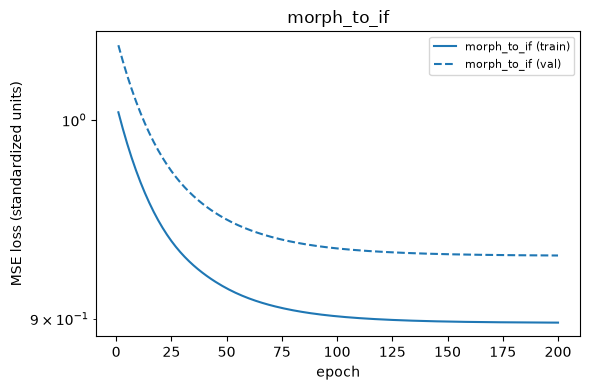

learned distance length scale: 25.2px


,R2,MAE
feature,,
HAND1_mean,0.216428,77.385817
BMP4_mean,0.071469,60.966188
T_mean,0.011598,17.455548


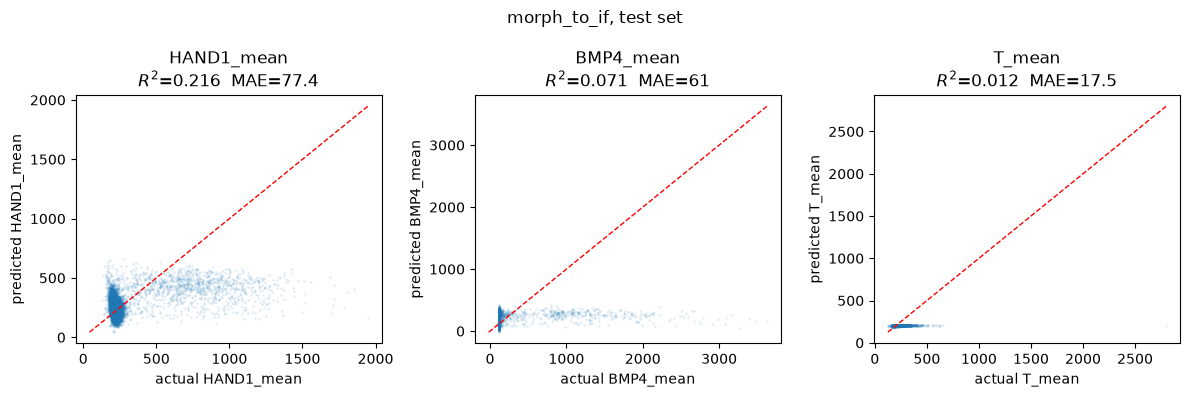

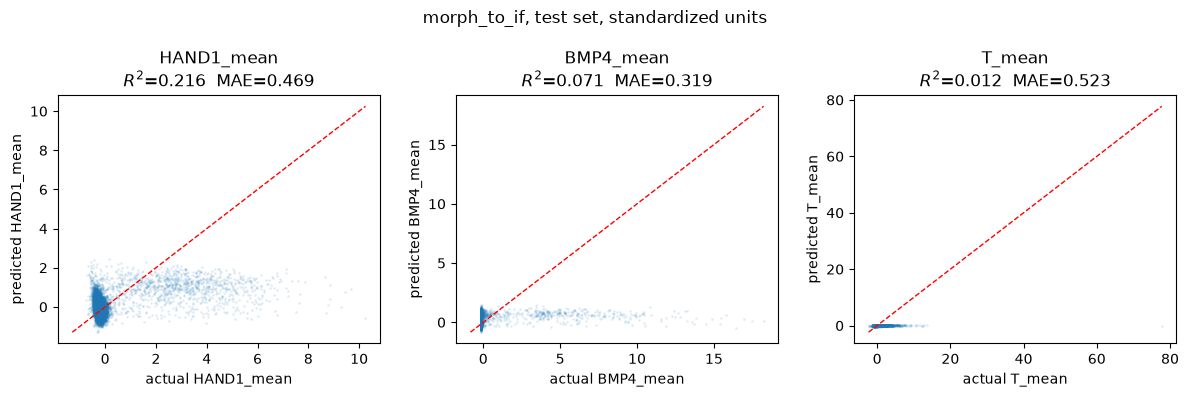

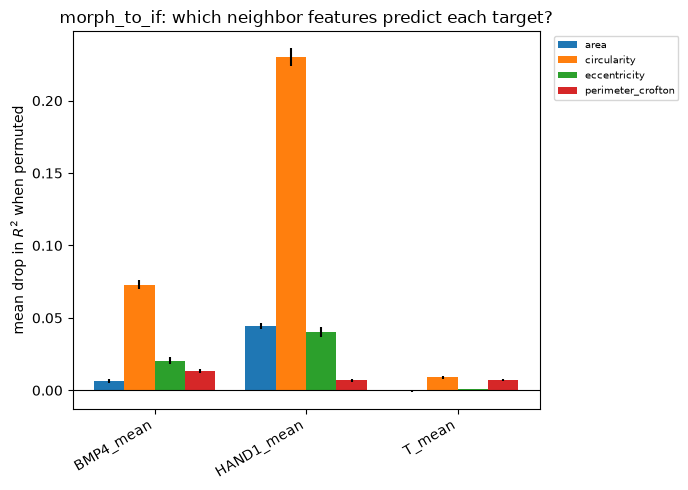


=== if_to_morph: neighbors' ['HAND1_mean', 'BMP4_mean', 'T_mean'] -> own ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


if_to_morph:   0%|          | 0/200 [00:00<?, ?it/s]

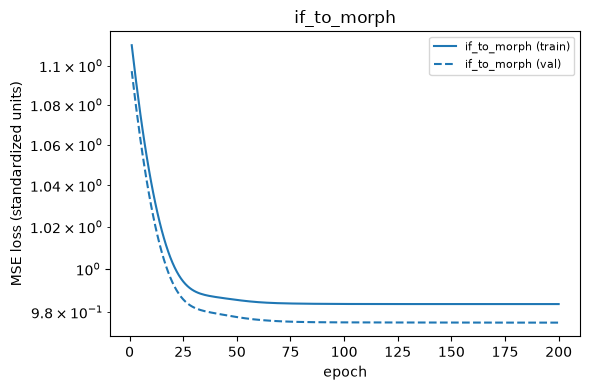

learned distance length scale: 24.8px


,R2,MAE
feature,,
area,0.021706,92.493100
perimeter_crofton,0.011159,9.271138
circularity,0.031275,0.051707
eccentricity,0.000860,0.112350


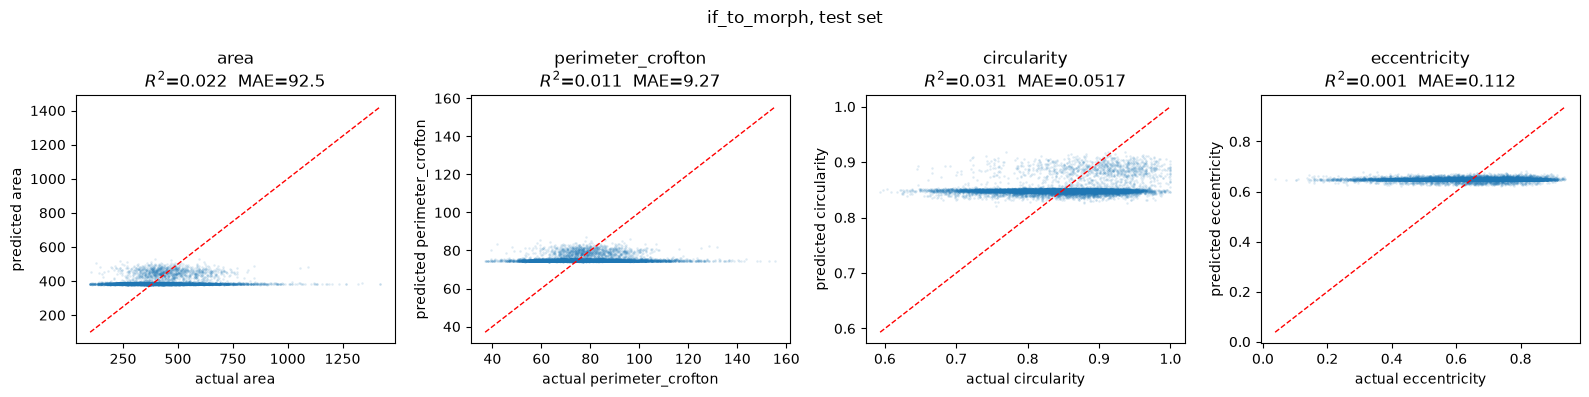

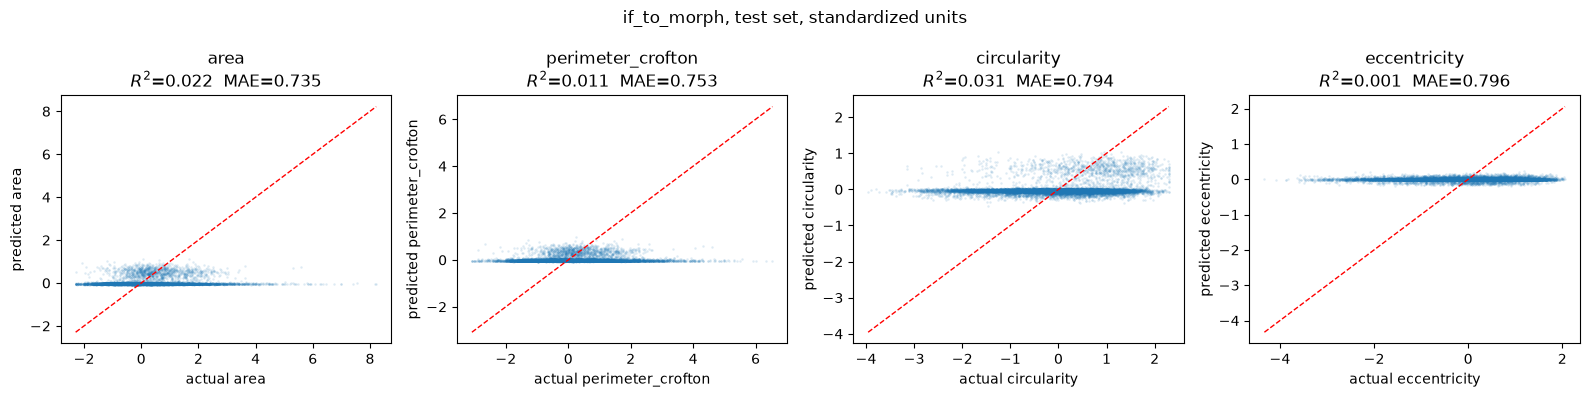

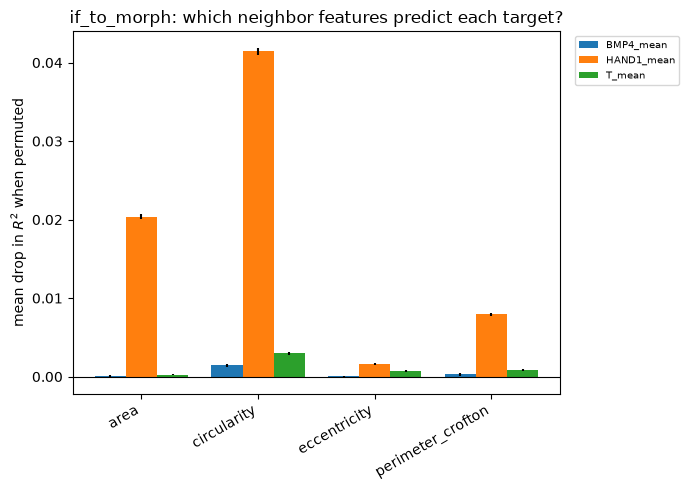


=== morph_to_morph: neighbors' ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] -> own ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


morph_to_morph:   0%|          | 0/200 [00:00<?, ?it/s]

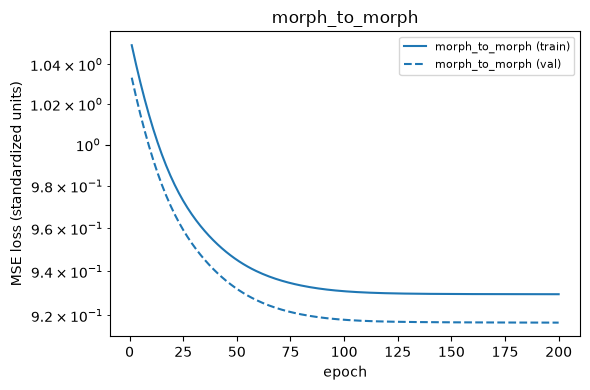

learned distance length scale: 24.8px


,R2,MAE
feature,,
area,0.113094,86.492472
perimeter_crofton,0.089518,8.754076
circularity,0.091485,0.049954
eccentricity,0.007754,0.112052


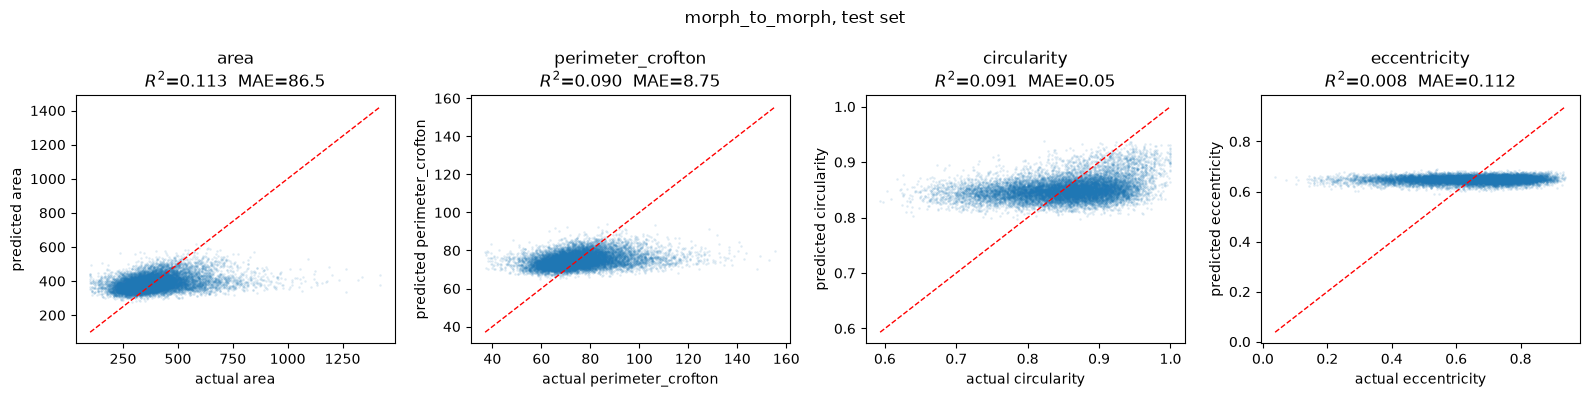

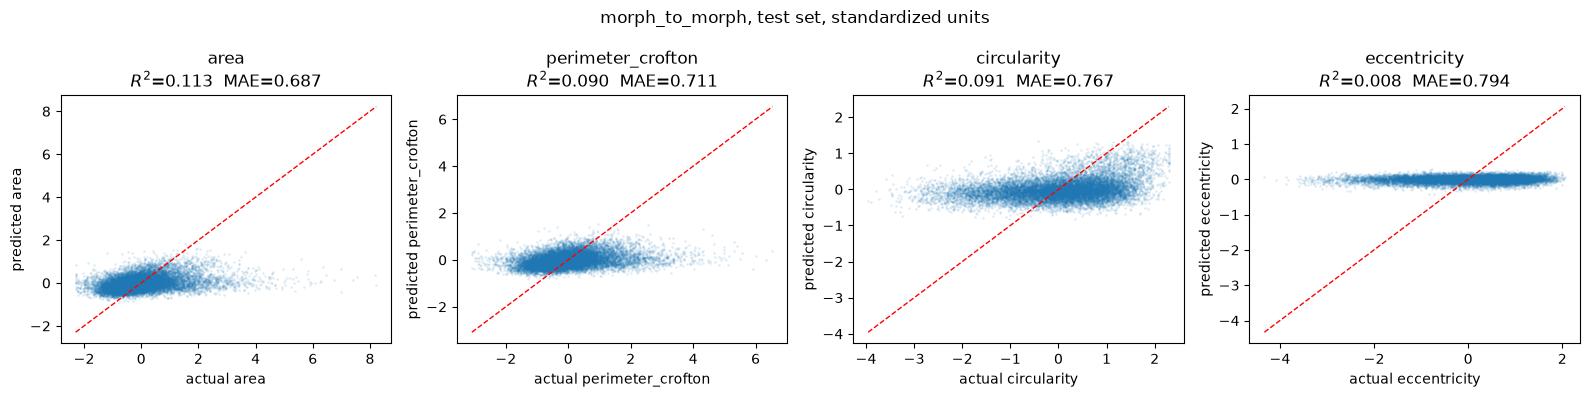

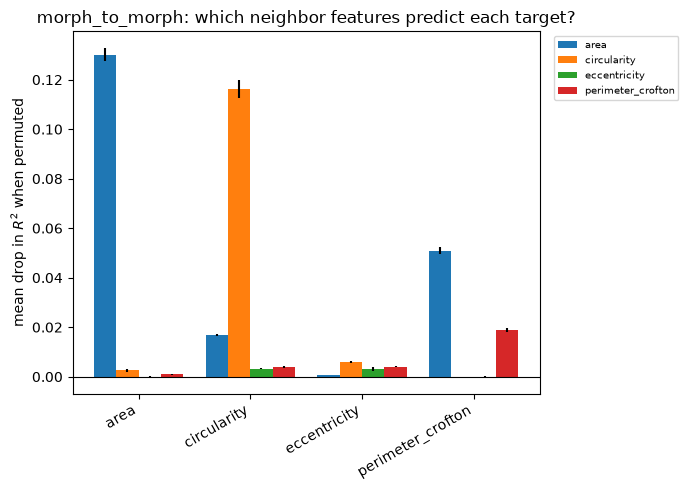


=== if_to_if: neighbors' ['HAND1_mean', 'BMP4_mean', 'T_mean'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


if_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

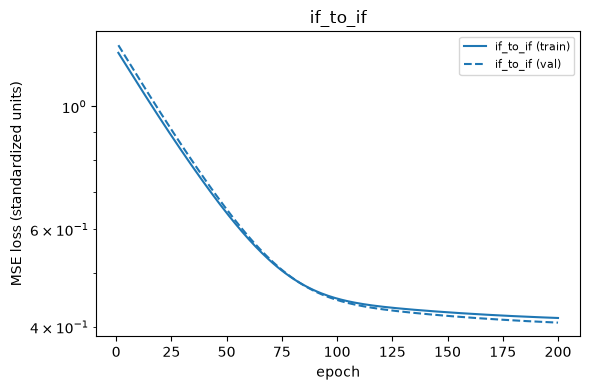

learned distance length scale: 24.8px


,R2,MAE
feature,,
HAND1_mean,0.771316,27.561885
BMP4_mean,0.510004,27.915938
T_mean,0.374095,9.906105


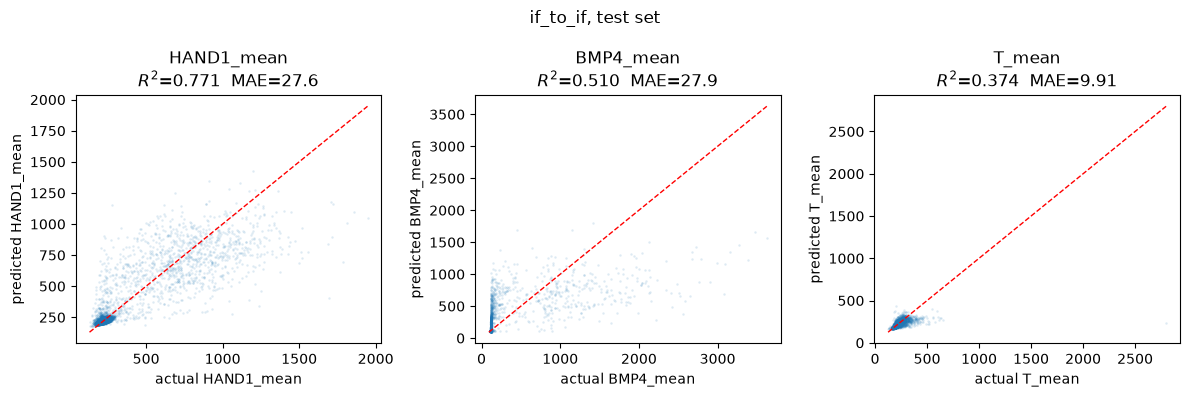

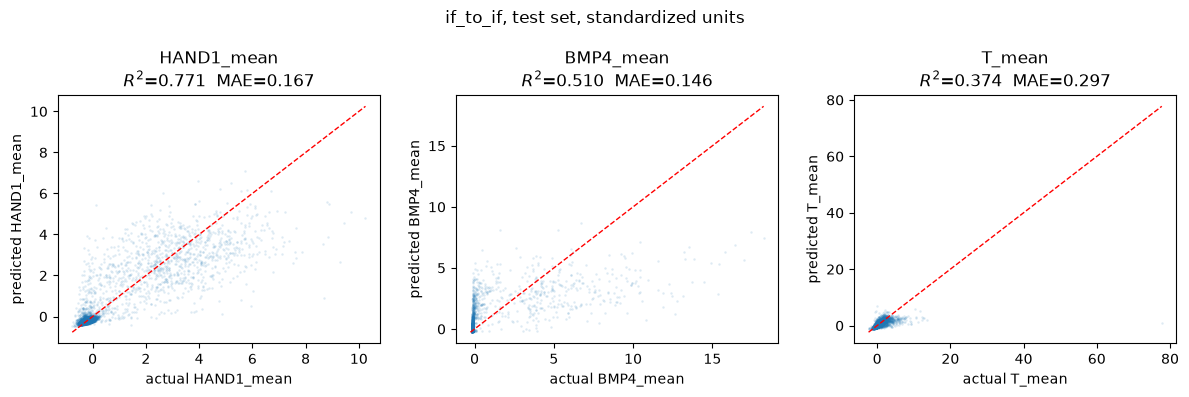

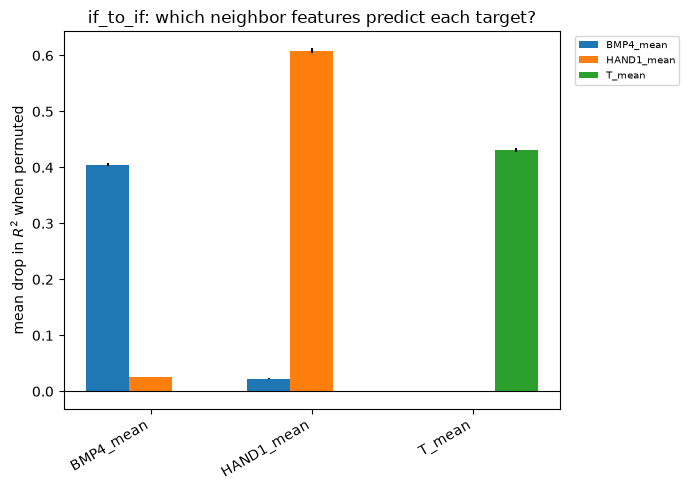


=== HAND1_to_if: neighbors' ['HAND1_mean'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


HAND1_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

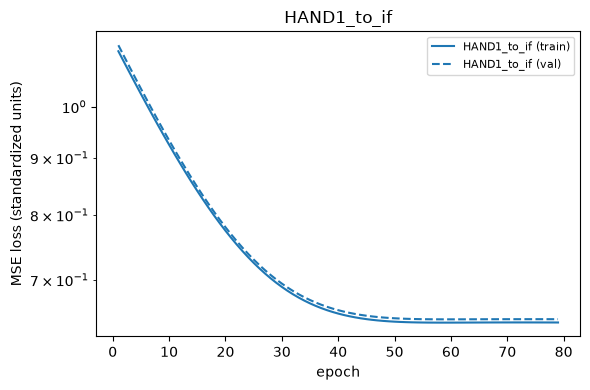

learned distance length scale: 24.9px


,R2,MAE
feature,,
HAND1_mean,0.777307,26.700295
BMP4_mean,0.316513,41.490307
T_mean,-0.000906,17.430823


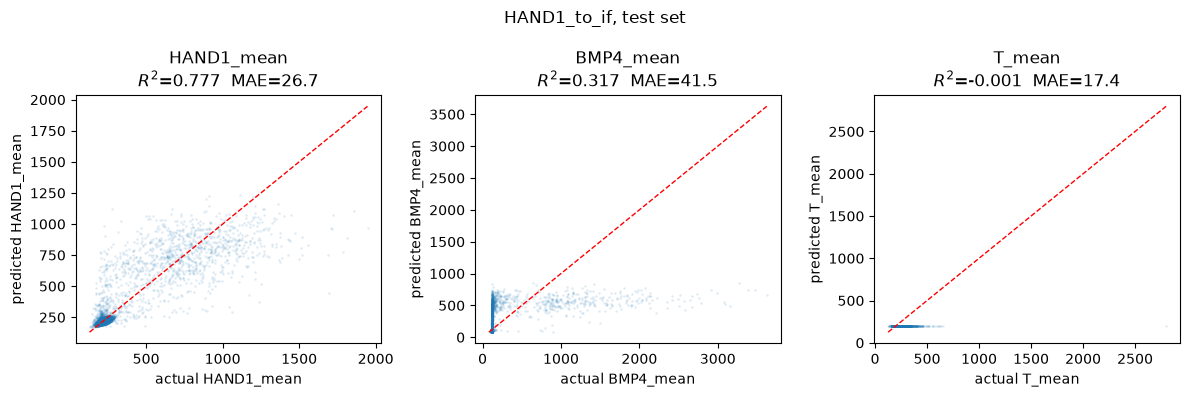

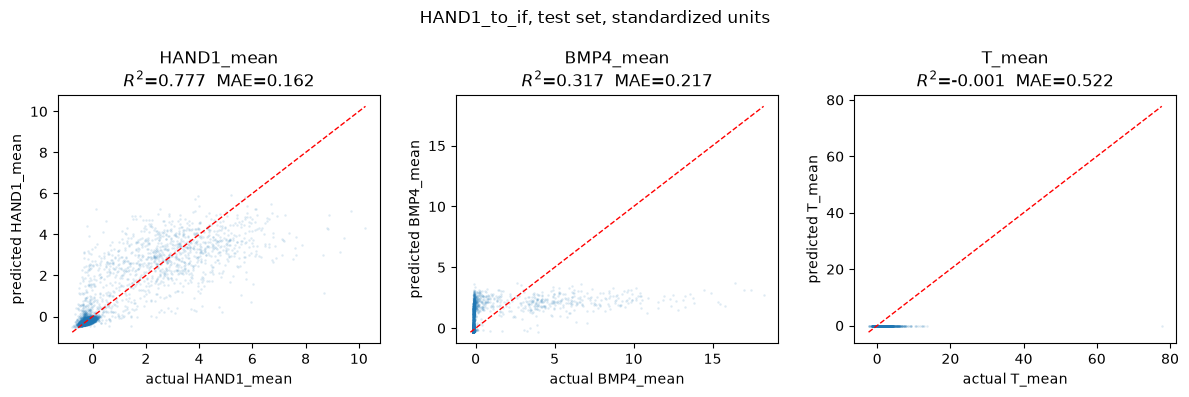

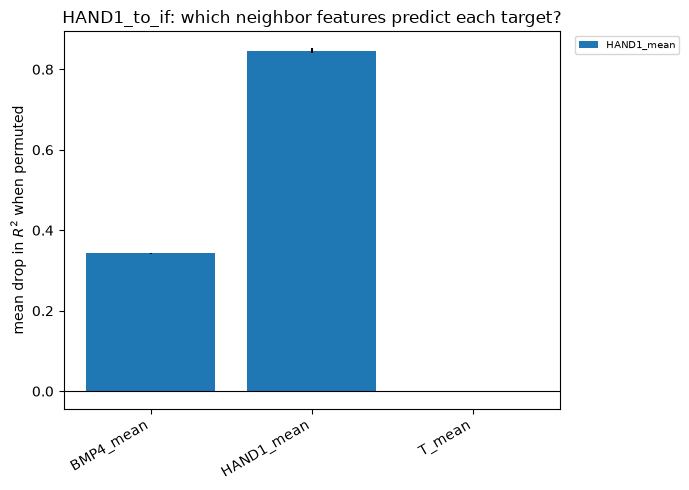


=== BMP4_to_if: neighbors' ['BMP4_mean'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


BMP4_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

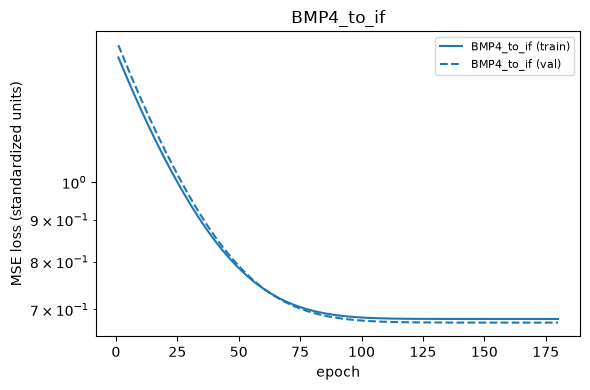

learned distance length scale: 25.0px


,R2,MAE
feature,,
HAND1_mean,0.481624,46.574402
BMP4_mean,0.521703,23.740244
T_mean,-0.000154,17.492259


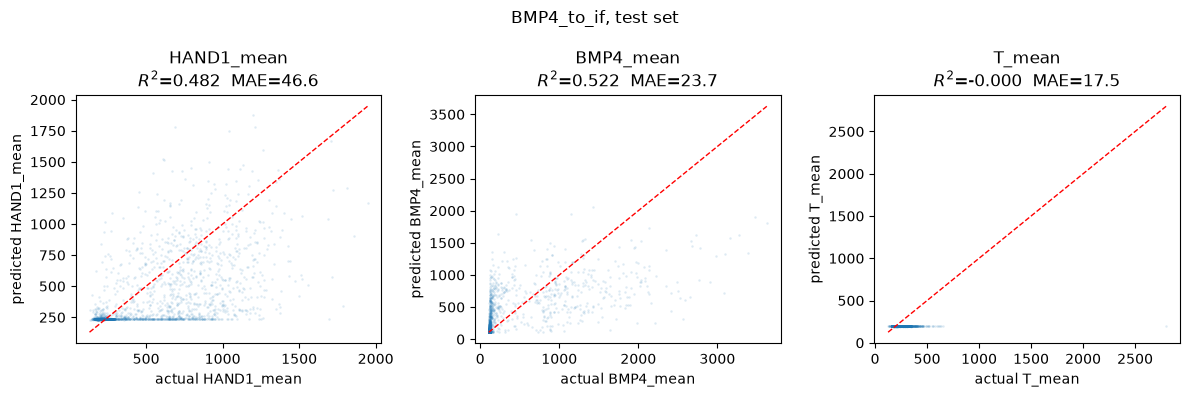

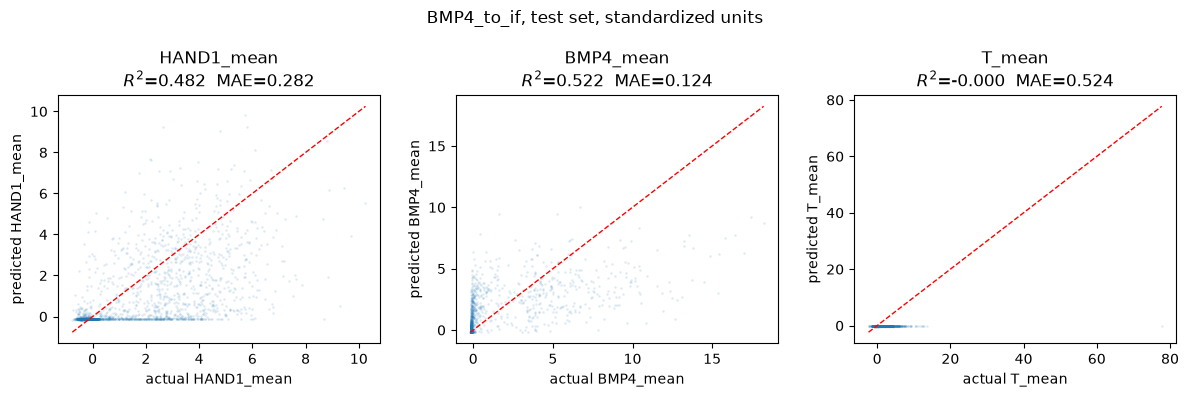

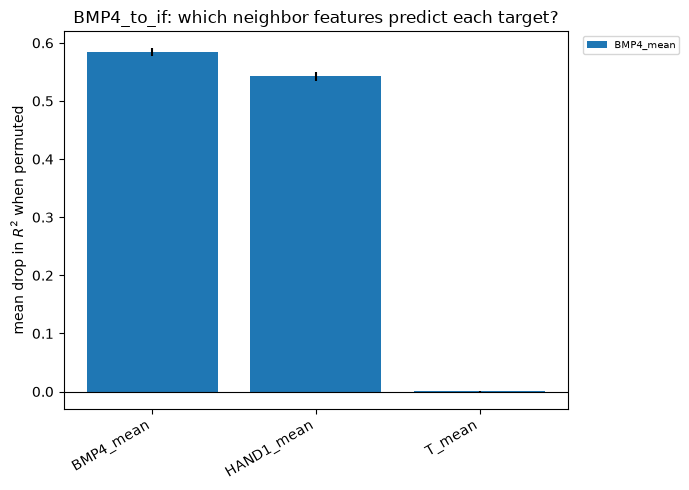


=== T_to_if: neighbors' ['T_mean'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


T_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

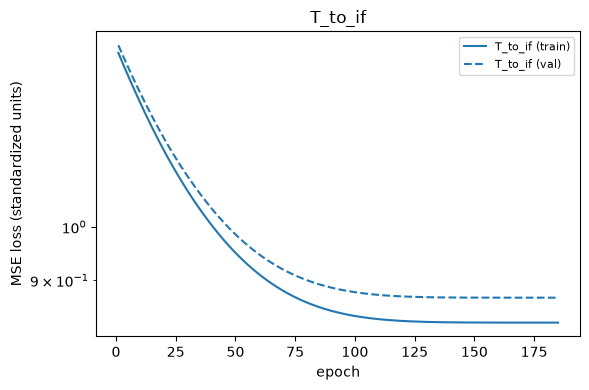

learned distance length scale: 24.9px


,R2,MAE
feature,,
HAND1_mean,-0.000198,74.981637
BMP4_mean,-0.000512,51.039562
T_mean,0.373904,9.897568


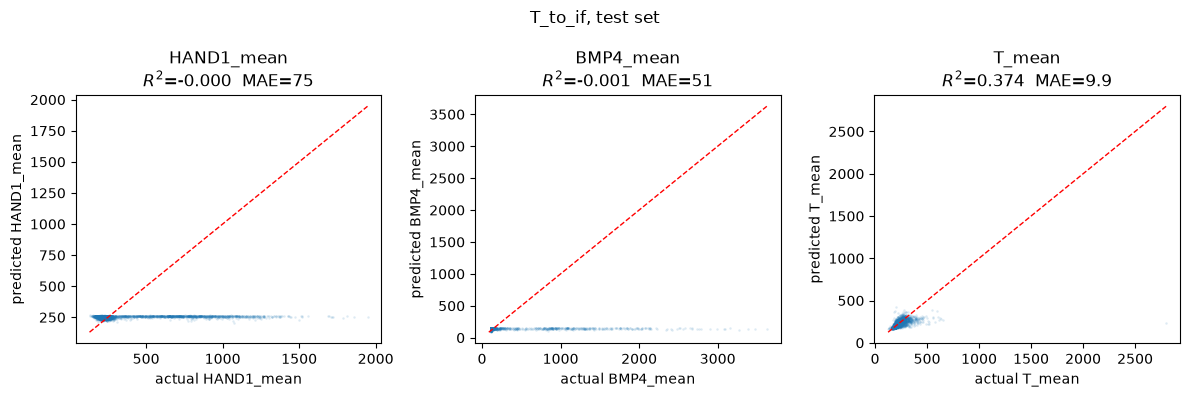

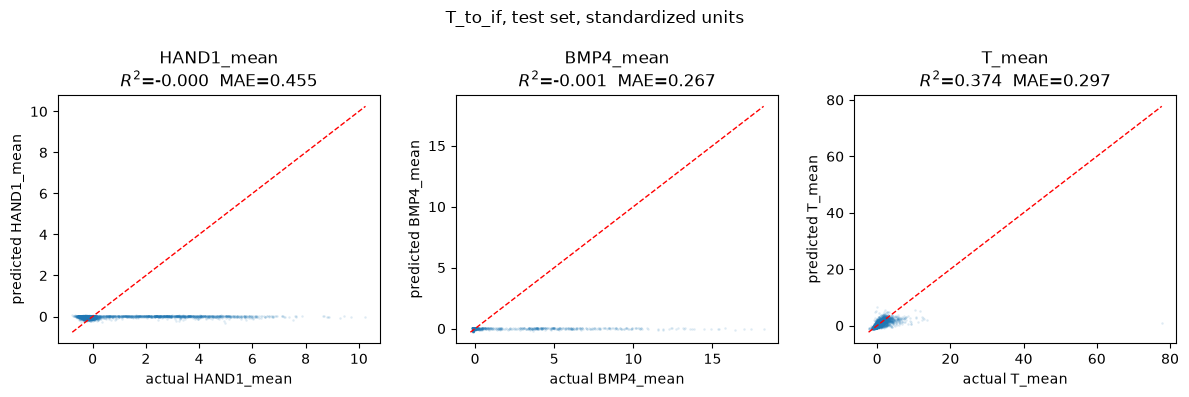

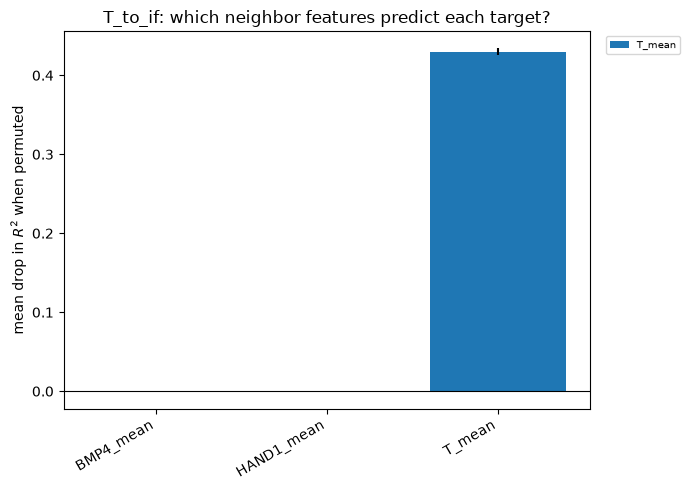


=== HAND1_to_morph: neighbors' ['HAND1_mean'] -> own ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


HAND1_to_morph:   0%|          | 0/200 [00:00<?, ?it/s]

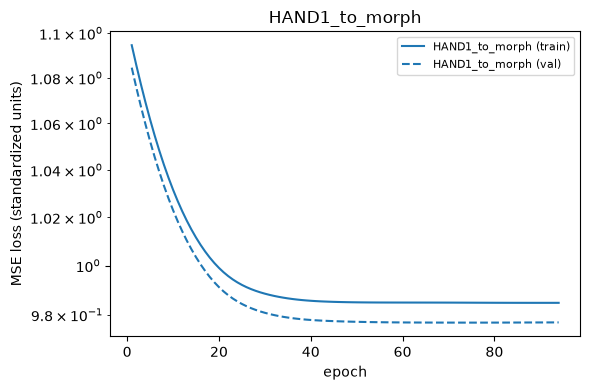

learned distance length scale: 24.9px


,R2,MAE
feature,,
area,0.021371,92.585978
perimeter_crofton,0.010329,9.275324
circularity,0.027882,0.051849
eccentricity,0.000426,0.112355


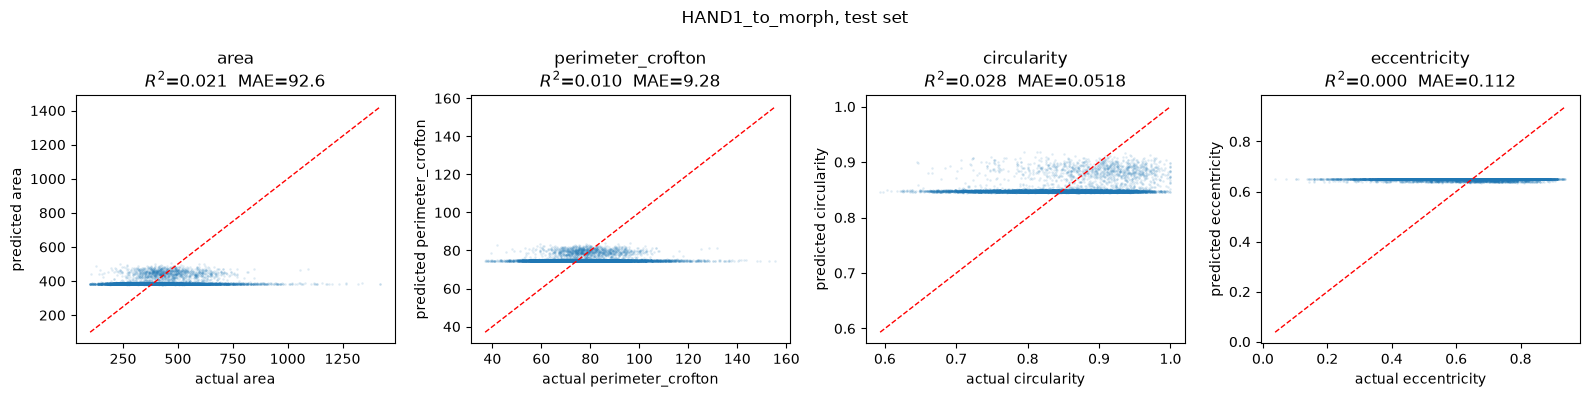

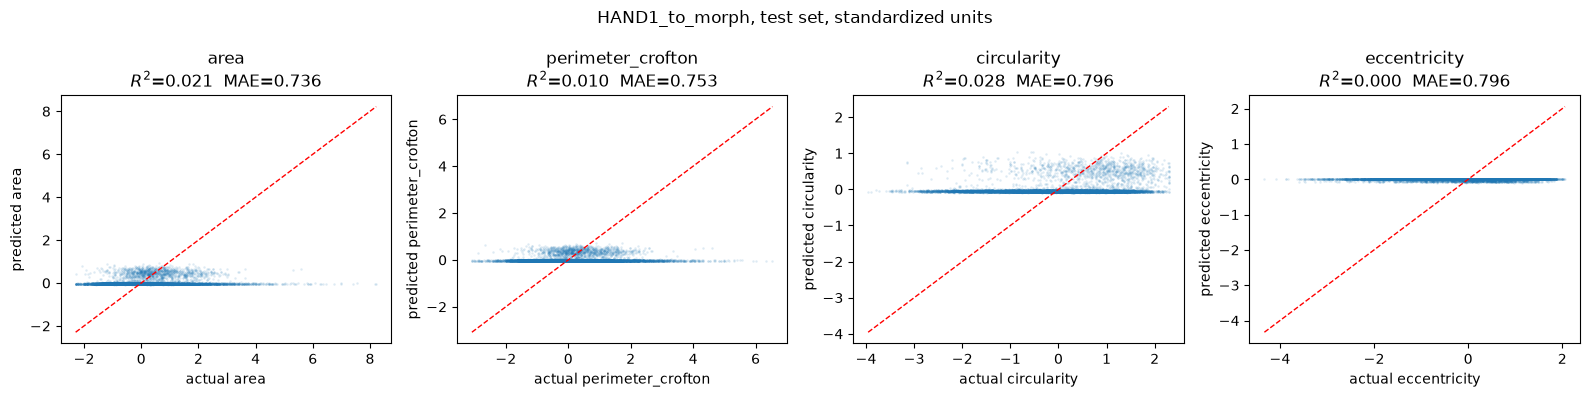

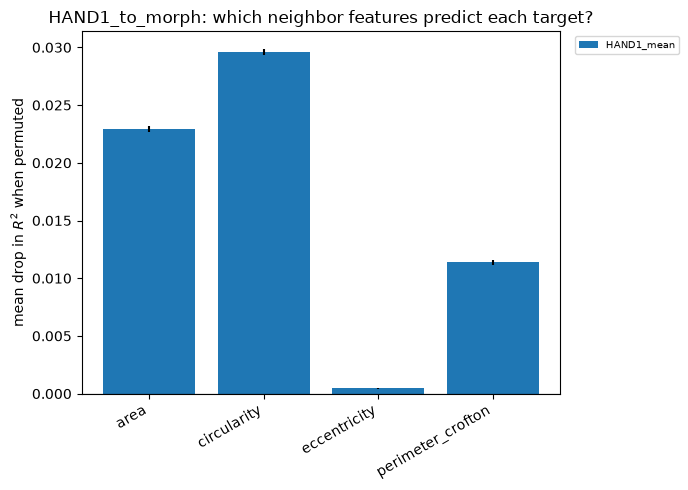


=== BMP4_to_morph: neighbors' ['BMP4_mean'] -> own ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


BMP4_to_morph:   0%|          | 0/200 [00:00<?, ?it/s]

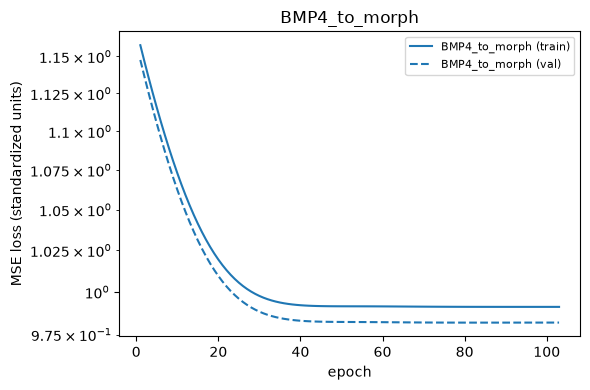

learned distance length scale: 24.9px


,R2,MAE
feature,,
area,0.013035,93.101906
perimeter_crofton,0.006989,9.300040
circularity,0.012281,0.052220
eccentricity,0.000154,0.112358


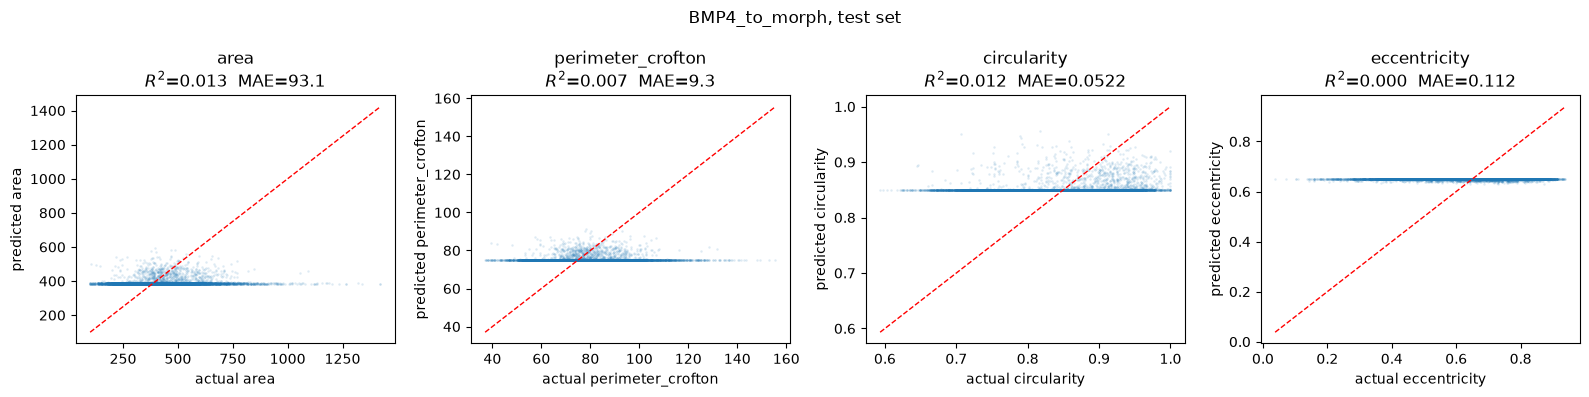

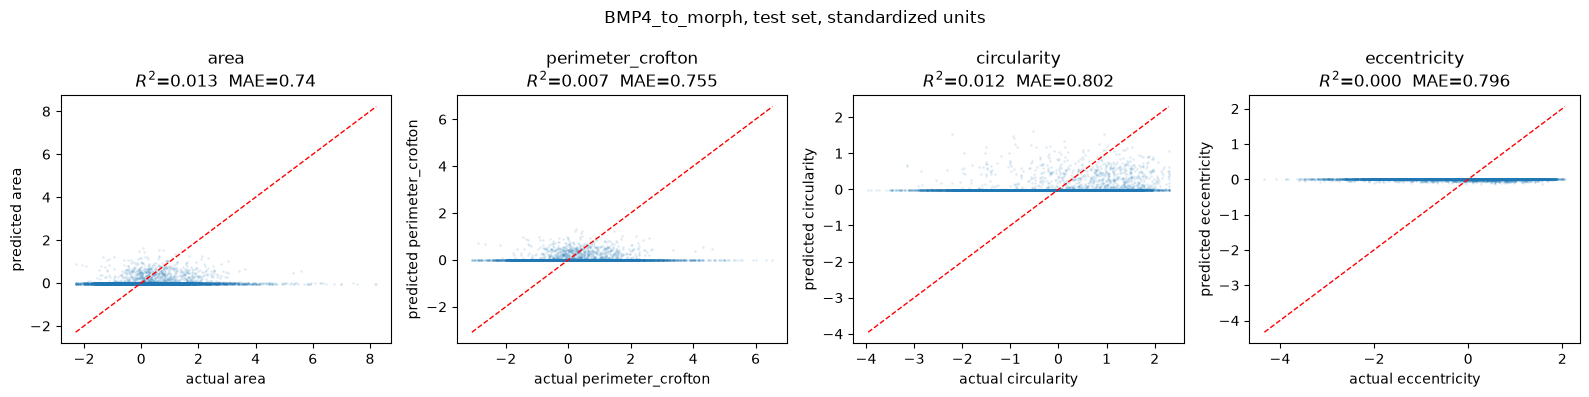

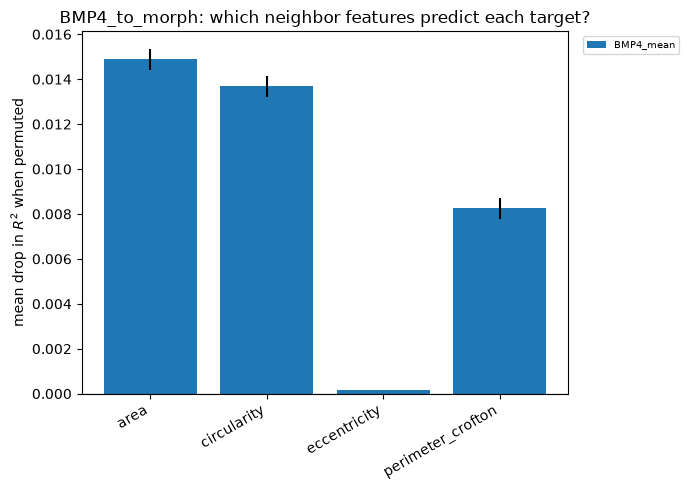


=== T_to_morph: neighbors' ['T_mean'] -> own ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


T_to_morph:   0%|          | 0/200 [00:00<?, ?it/s]

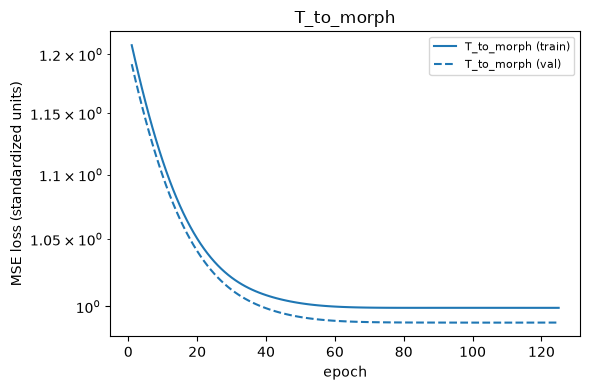

learned distance length scale: 24.9px


,R2,MAE
feature,,
area,0.000036,94.079655
perimeter_crofton,0.000549,9.354333
circularity,0.002895,0.052458
eccentricity,0.000446,0.112367


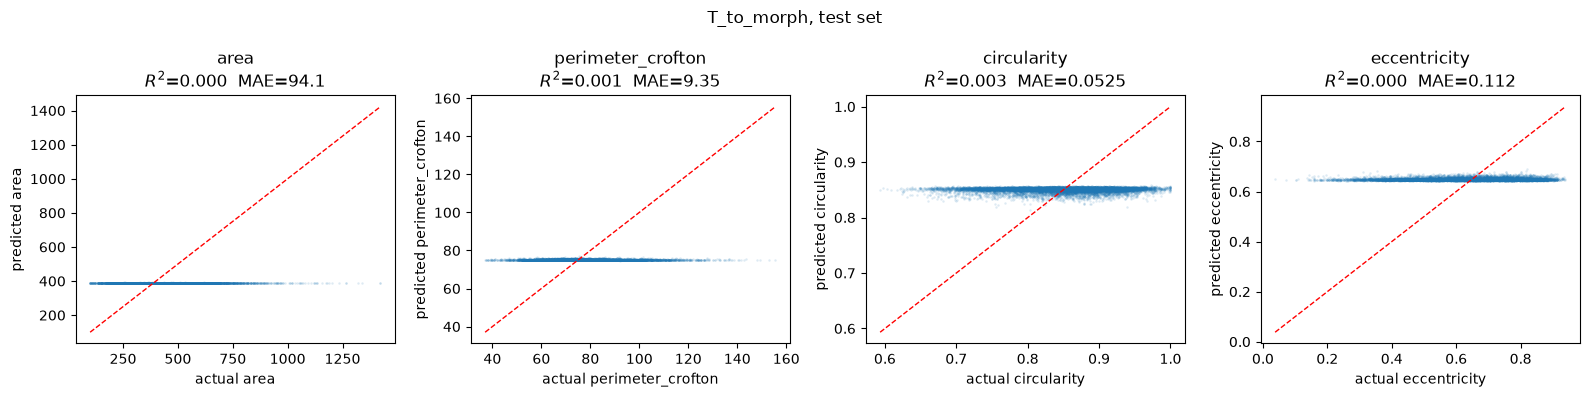

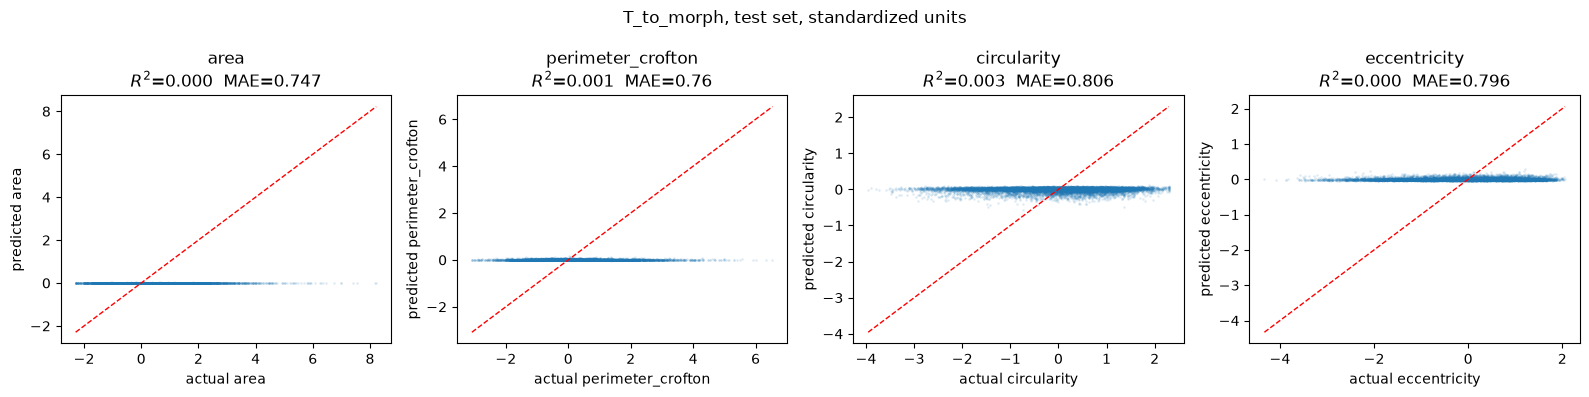

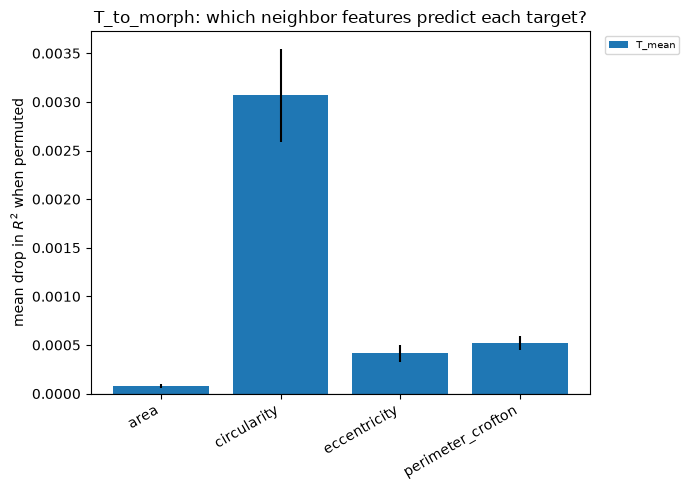


=== other_if_to_HAND1_mean: neighbors' ['BMP4_mean', 'T_mean'] -> own ['HAND1_mean'] ===


other_if_to_HAND1_mean:   0%|          | 0/200 [00:00<?, ?it/s]

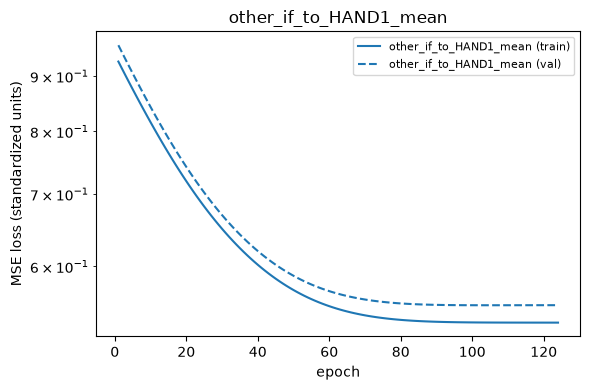

learned distance length scale: 25.1px


,R2,MAE
feature,,
HAND1_mean,0.481586,46.801283


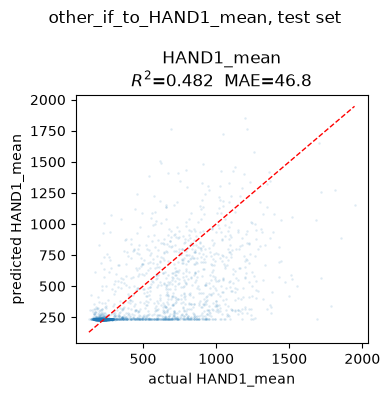

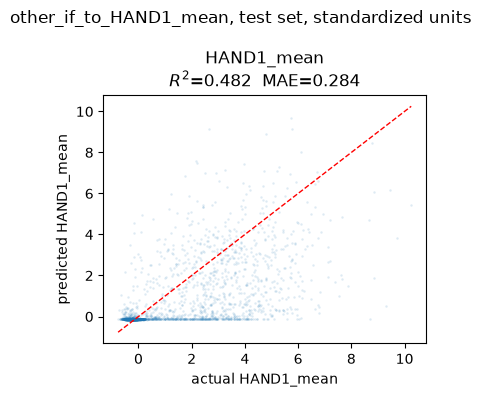

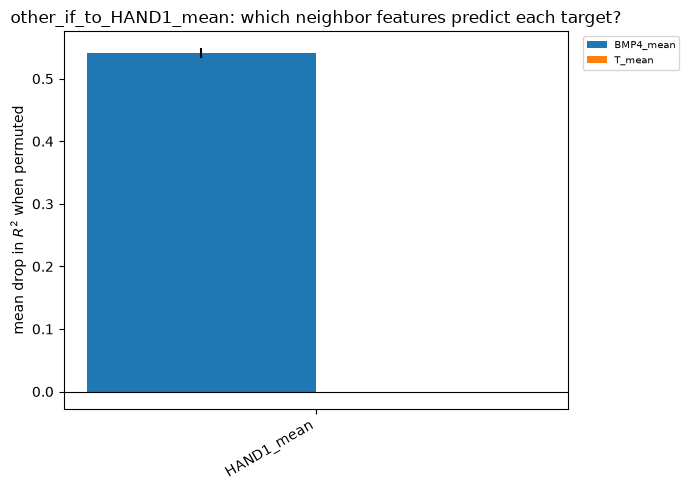


=== other_if_to_BMP4_mean: neighbors' ['HAND1_mean', 'T_mean'] -> own ['BMP4_mean'] ===


other_if_to_BMP4_mean:   0%|          | 0/200 [00:00<?, ?it/s]

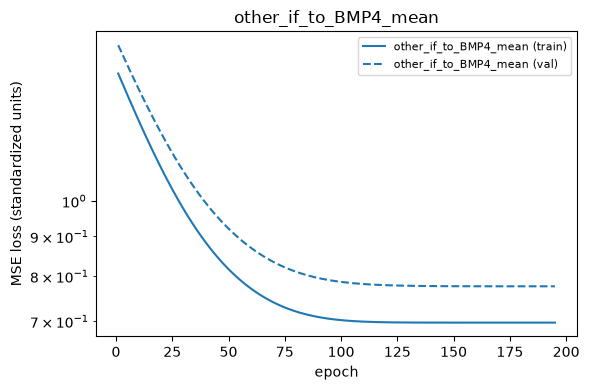

learned distance length scale: 24.8px


,R2,MAE
feature,,
BMP4_mean,0.316047,40.622863


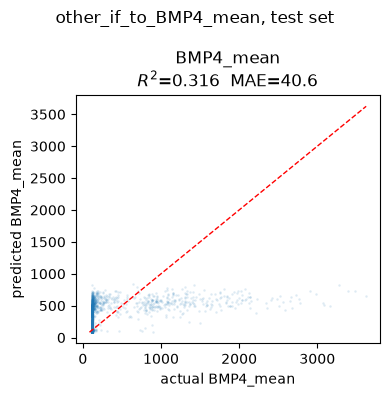

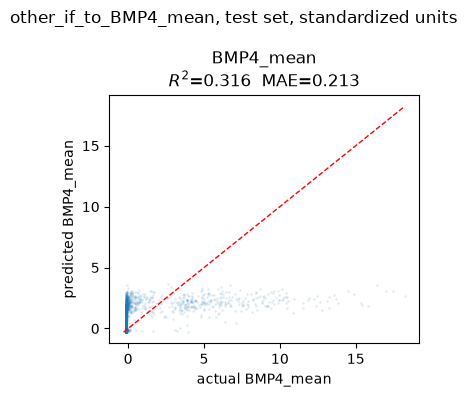

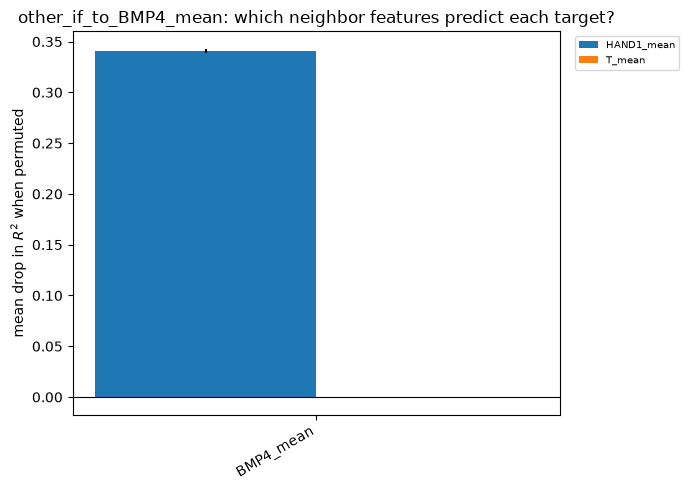


=== other_if_to_T_mean: neighbors' ['HAND1_mean', 'BMP4_mean'] -> own ['T_mean'] ===


other_if_to_T_mean:   0%|          | 0/200 [00:00<?, ?it/s]

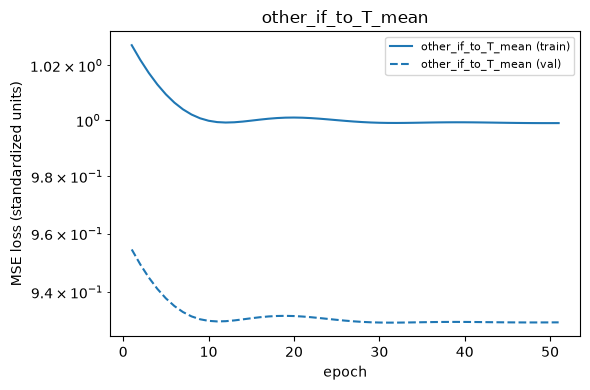

learned distance length scale: 25.0px


,R2,MAE
feature,,
T_mean,-0.000689,17.497056


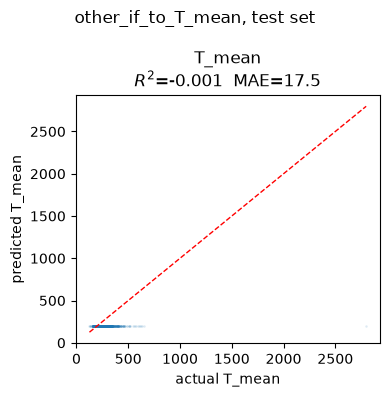

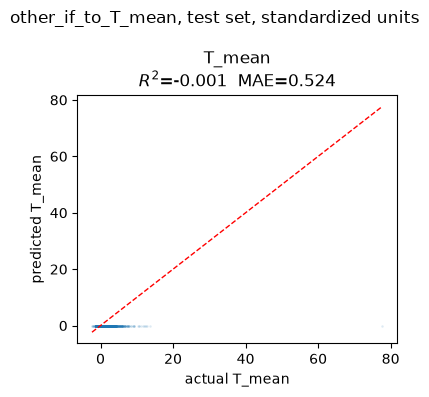

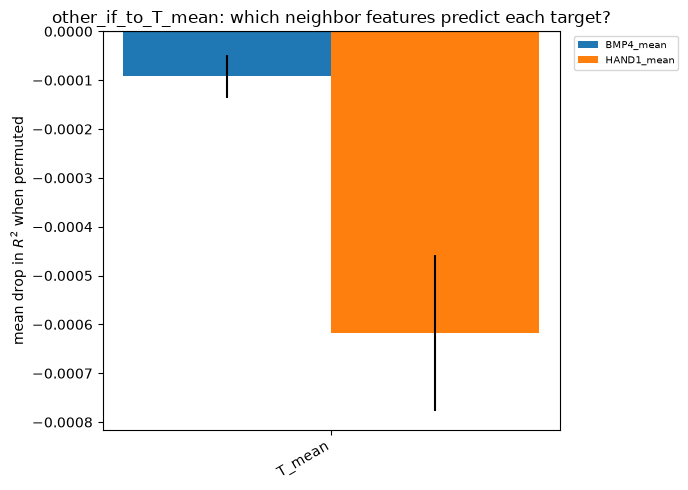

In [9]:
results = {
    name: run_neighbor_experiment(
        name, cfg['neighbor_cols'], cfg['target_cols'],
        **{k: v for k, v in cfg.items() if k not in ('neighbor_cols', 'target_cols')},
    )
    for name, cfg in EXPERIMENTS.items()
}

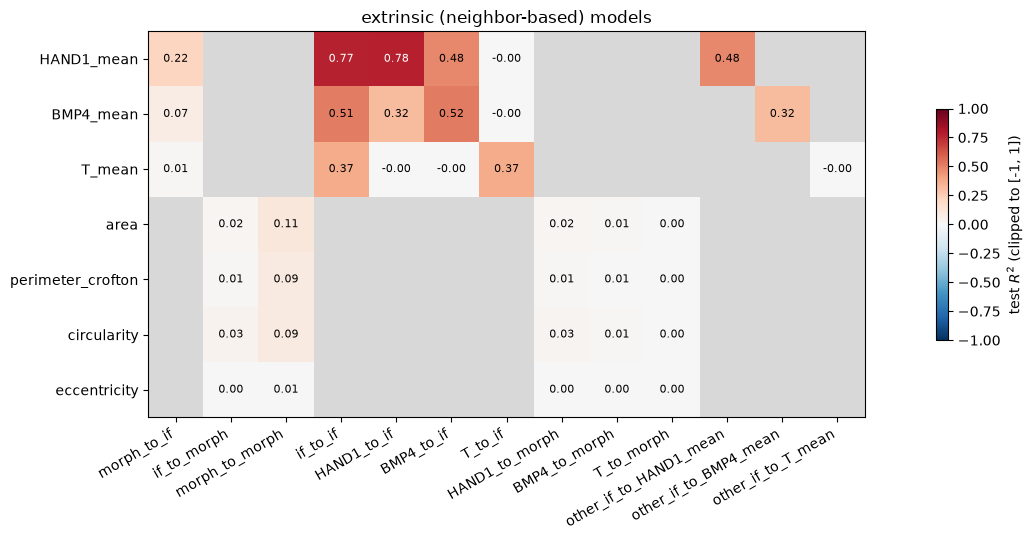

experiment,morph_to_if,if_to_morph,morph_to_morph,if_to_if,HAND1_to_if,BMP4_to_if,T_to_if,HAND1_to_morph,BMP4_to_morph,T_to_morph,other_if_to_HAND1_mean,other_if_to_BMP4_mean,other_if_to_T_mean
target,,,,,,,,,,,,,
HAND1_mean,0.216428,NaN,NaN,0.771316,0.777307,0.481624,-0.000198,NaN,NaN,NaN,0.481586,NaN,NaN
BMP4_mean,0.071469,NaN,NaN,0.510004,0.316513,0.521703,-0.000512,NaN,NaN,NaN,NaN,0.316047,NaN
T_mean,0.011598,NaN,NaN,0.374095,-0.000906,-0.000154,0.373904,NaN,NaN,NaN,NaN,NaN,-0.000689
area,NaN,0.021706,0.113094,NaN,NaN,NaN,NaN,0.021371,0.013035,0.000036,NaN,NaN,NaN
perimeter_crofton,NaN,0.011159,0.089518,NaN,NaN,NaN,NaN,0.010329,0.006989,0.000549,NaN,NaN,NaN
circularity,NaN,0.031275,0.091485,NaN,NaN,NaN,NaN,0.027882,0.012281,0.002895,NaN,NaN,NaN
eccentricity,NaN,0.000860,0.007754,NaN,NaN,NaN,NaN,0.000426,0.000154,0.000446,NaN,NaN,NaN


In [10]:
target_cols_by_experiment = {name: cfg['target_cols'] for name, cfg in EXPERIMENTS.items()}
summary = plot_experiment_comparison(
    results, target_cols_by_experiment, title='extrinsic (neighbor-based) models'
)
display(summary)


## Does neighborhood density matter? Radius-based graph

The `k=K` graph above fixes the same NUMBER of neighbors for every cell, which fixes
away local density as a variable: a cell in a dense region draws its `K` neighbors from
a small radius, a cell in a sparse region draws them from a much larger one, so "K
neighbors" doesn't correspond to the same physical neighborhood size everywhere.

`radius_edge_index` (`tools/graph.py`) connects every pair of cells within a fixed
PHYSICAL distance instead -- so the NUMBER of neighbors becomes a direct readout of
local density (more neighbors in a dense region, fewer in a sparse one). GNN message
passing doesn't require a fixed node degree, so this plugs into the exact same
`NeighborFeaturePredictor`/`run_neighbor_experiment` pipeline used above, just with a
different graph.

**Choosing the radius**: on this data (mean cell diameter ~22px, k=20's neighbors sit
~55px away on average), 600px would connect every cell to ~2,300 others -- a huge chunk
of the whole tissue, not a "neighborhood", and ~220M+ edges is impractical to train on.
75px (~3-4 cell diameters, a bit past k=20's own reach) gives a genuinely local
neighborhood with real degree variation (about 25-56 neighbors depending on local
density) at a manageable ~3.7M edges -- similar order of magnitude to the k=20 graph.

In [ ]:
from tools.morphology import radius_edge_index, local_density

RADIUS = 200  # px -- see rationale above; sweep this if you want to check sensitivity

radius_edge_index_np, radius_edge_dist_np = radius_edge_index(centroids, radius=RADIUS, min_neighbors=3)
radius_edge_index_t = torch.from_numpy(radius_edge_index_np)
radius_edge_attr_t = torch.from_numpy(radius_edge_dist_np).unsqueeze(-1)

# explicit density feature: message-passing aggregators (mean/attention, as used by
# NeighborOnlyGNN here) largely normalize away raw neighbor count, so the graph
# structure alone doesn't reliably give the model a density readout -- this does.
cell_df['local_density'] = local_density(centroids, radius=RADIUS)

degree = np.bincount(radius_edge_index_np[0], minlength=N)
print(f'{N} cells, {radius_edge_index_t.shape[1]} directed edges (radius={RADIUS}px)')
print(f'neighbors per cell: mean={degree.mean():.1f}, median={np.median(degree):.0f}, min={degree.min()}, max={degree.max()}')


=== morph_to_if: neighbors' ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


morph_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

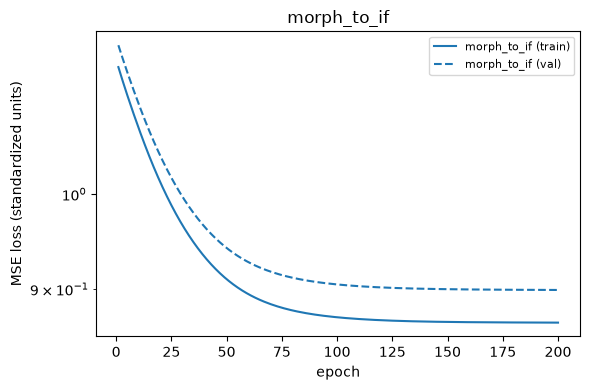

learned distance length scale: 25.2px


,R2,MAE
feature,,
HAND1_mean,0.280275,74.913351
BMP4_mean,0.098728,61.443474
T_mean,0.012479,17.418152


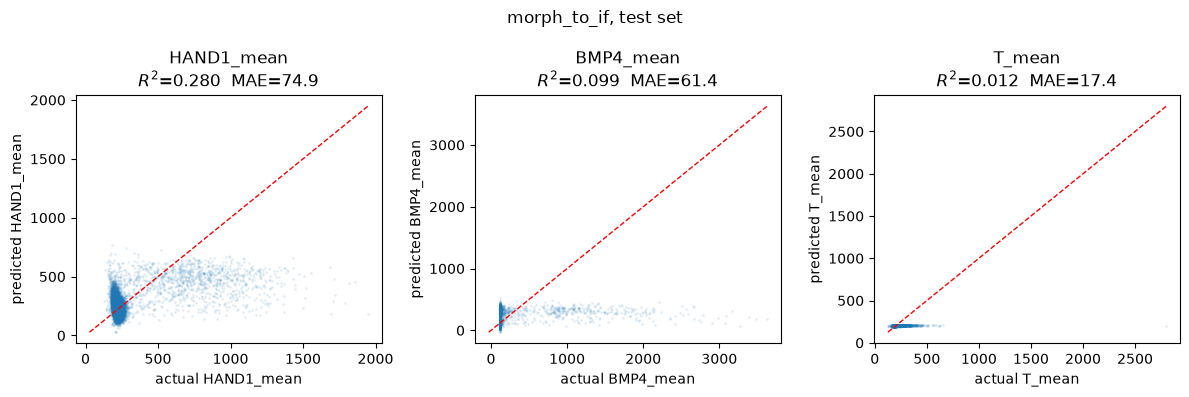

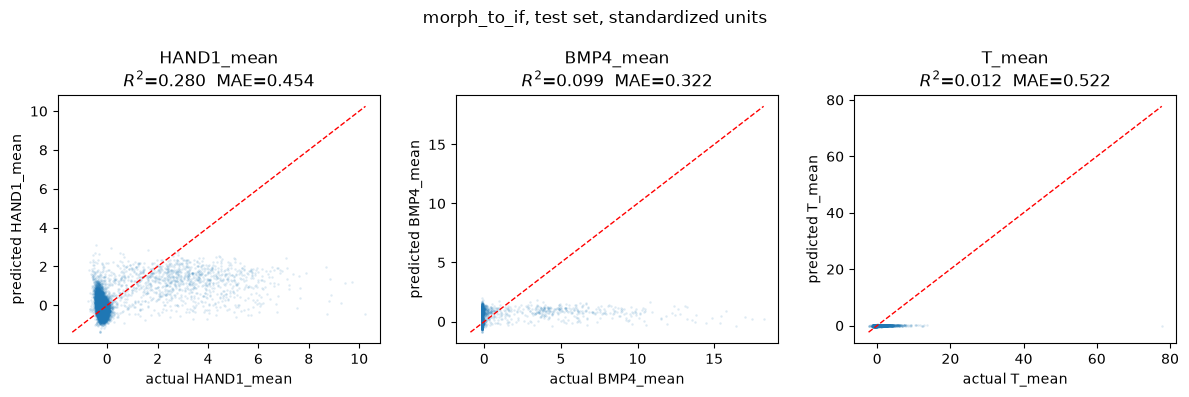

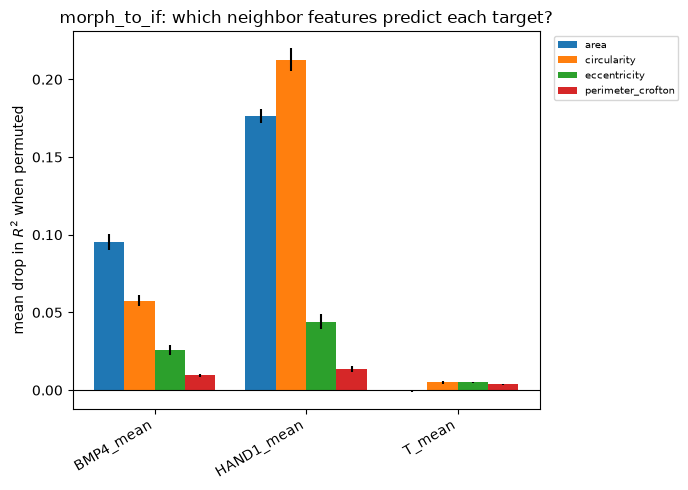


=== if_to_morph: neighbors' ['HAND1_mean', 'BMP4_mean', 'T_mean'] -> own ['area', 'perimeter_crofton', 'circularity', 'eccentricity'] ===


if_to_morph:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# Same EXPERIMENTS dict, same targets, only the graph changes -- directly comparable
# to `results`/`summary` above.
radius_results = {
    name: run_neighbor_experiment(
        name, cfg['neighbor_cols'], cfg['target_cols'],
        edge_index=radius_edge_index_t, edge_attr=radius_edge_attr_t,
        **{k: v for k, v in cfg.items() if k not in ('neighbor_cols', 'target_cols')},
    )
    for name, cfg in EXPERIMENTS.items()
}

In [ ]:
target_cols_by_experiment = {name: cfg['target_cols'] for name, cfg in EXPERIMENTS.items()}


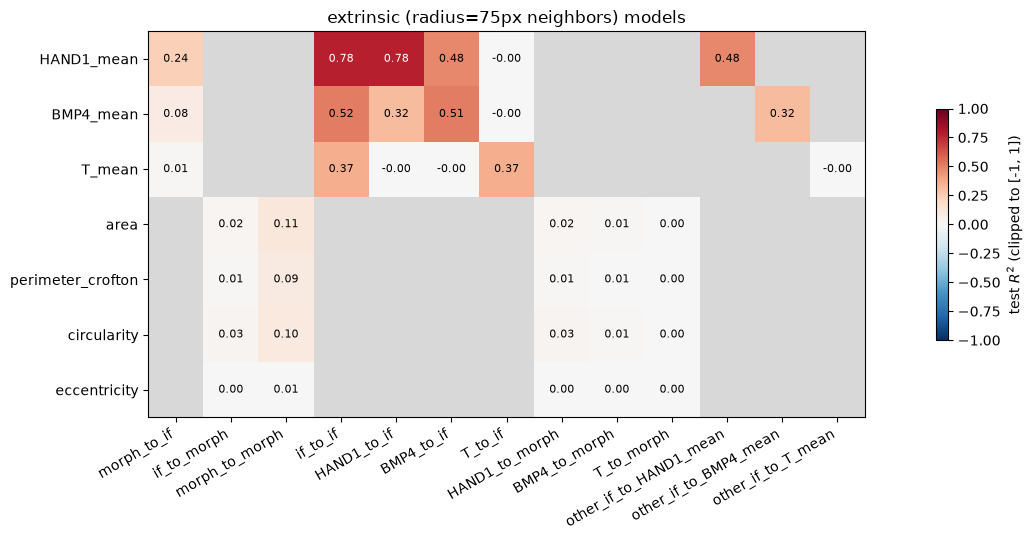

experiment,morph_to_if,if_to_morph,morph_to_morph,if_to_if,HAND1_to_if,BMP4_to_if,T_to_if,HAND1_to_morph,BMP4_to_morph,T_to_morph,other_if_to_HAND1_mean,other_if_to_BMP4_mean,other_if_to_T_mean
target,,,,,,,,,,,,,
HAND1_mean,0.238266,NaN,NaN,0.777861,0.776633,0.482893,-0.000017,NaN,NaN,NaN,0.482771,NaN,NaN
BMP4_mean,0.080097,NaN,NaN,0.515323,0.317720,0.514968,-0.000483,NaN,NaN,NaN,NaN,0.317119,NaN
T_mean,0.012207,NaN,NaN,0.366663,-0.000406,-0.000028,0.366223,NaN,NaN,NaN,NaN,NaN,-0.001048
area,NaN,0.021616,0.114562,NaN,NaN,NaN,NaN,0.021547,0.013192,0.000054,NaN,NaN,NaN
perimeter_crofton,NaN,0.011130,0.091116,NaN,NaN,NaN,NaN,0.010373,0.007063,0.000594,NaN,NaN,NaN
circularity,NaN,0.031027,0.096491,NaN,NaN,NaN,NaN,0.028146,0.012545,0.002799,NaN,NaN,NaN
eccentricity,NaN,0.000988,0.007459,NaN,NaN,NaN,NaN,0.000482,0.000107,0.000510,NaN,NaN,NaN


NameError: name 'summary' is not defined

In [ ]:
radius_summary = plot_experiment_comparison(
    radius_results, target_cols_by_experiment, title=f'extrinsic (radius={RADIUS}px neighbors) models'
)
display(radius_summary)


=== morph_and_density_to_if: neighbors' ['area', 'perimeter_crofton', 'circularity', 'eccentricity', 'local_density'] -> own ['HAND1_mean', 'BMP4_mean', 'T_mean'] ===


morph_and_density_to_if:   0%|          | 0/200 [00:00<?, ?it/s]

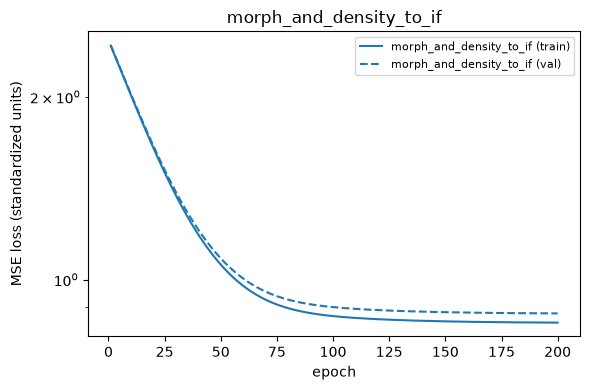

learned distance length scale: 25.1px


,R2,MAE
feature,,
HAND1_mean,0.318285,73.532728
BMP4_mean,0.111571,64.441398
T_mean,0.014265,17.479320


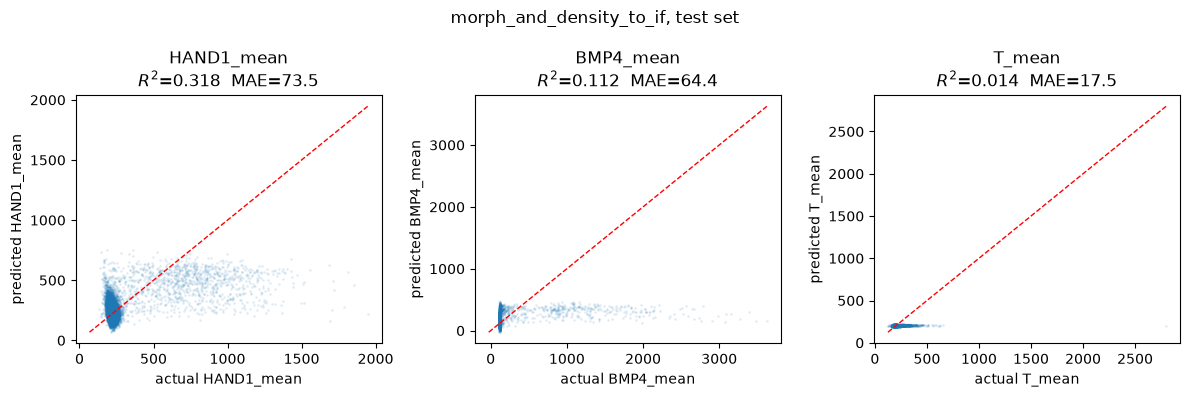

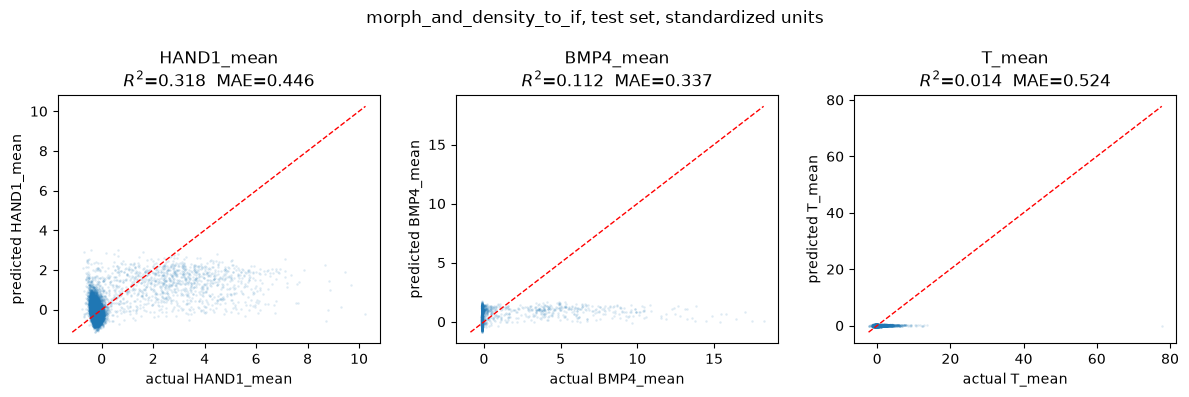

KeyboardInterrupt: 

In [ ]:
# Does adding local_density as an EXPLICIT input feature help, on top of whatever the
# graph structure already encodes implicitly (mean/attention aggregation mostly
# normalizes raw neighbor count away -- see the markdown above)?
density_result = run_neighbor_experiment(
    'morph_and_density_to_if', morphology_cols + ['local_density'], if_cols,
    edge_index=radius_edge_index_t, edge_attr=radius_edge_attr_t,
)
print('R^2 without density (radius-based morph_to_if):')
display(radius_results['morph_to_if']['r2'])
print('R^2 WITH local_density as an explicit feature:')
display(density_result['r2'])

### Spatial cross-correlation (bivariate Moran's I)

Same idea as the Pearson correlation heatmap in `intrinsic.ipynb`, but spatial: each cell in
the matrix asks whether feature A at a cell sits next to feature B at its *neighbors* (using
the same `k=K` graph built above), not whether A and B move together within the same cell. The
diagonal is the ordinary single-feature Moran's I (positive = spatially clustered/patchy, e.g.
what you'd expect near an optogenetically activated region; negative = spatially dispersed).

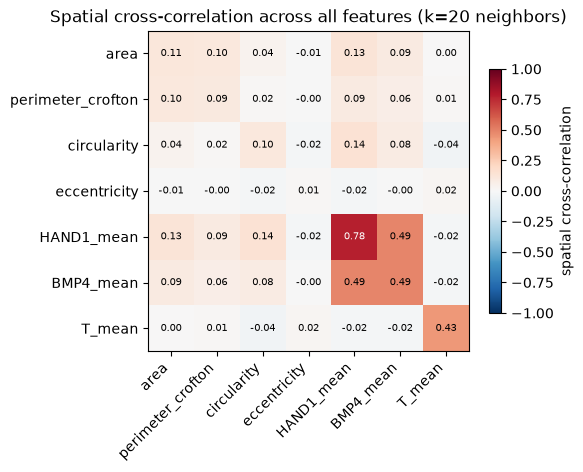

,feature_1,feature_2,r
0,HAND1_mean,BMP4_mean,0.490248
1,circularity,HAND1_mean,0.143361
2,area,HAND1_mean,0.130278
3,area,perimeter_crofton,0.101658
4,perimeter_crofton,HAND1_mean,0.091900
5,area,BMP4_mean,0.086166
6,circularity,BMP4_mean,0.080408
7,perimeter_crofton,BMP4_mean,0.064126
8,area,circularity,0.039033
9,circularity,T_mean,-0.035172


In [ ]:
fig, spatial_corr = plot_spatial_cross_correlation(
    cell_df, morphology_cols + if_cols, edge_index,
    title=f'Spatial cross-correlation across all features (k={K} neighbors)',
)
plt.show()

display(top_correlated_pairs(spatial_corr, n=15))


## Next steps

- **Compare to `intrinsic.ipynb`**: if the cell-autonomous $R^2$ (same target, predicted
  from the cell's OWN other features) is much higher than the neighbor-only $R^2$ here,
  that feature looks cell-intrinsic; if extrinsic catches up, that's evidence for a real
  community/paracrine effect. `morph_to_morph`/`if_to_if` above test the same-modality
  case -- e.g. do neighboring cells just have similar shapes/marker levels regardless of
  cross-modality coupling?
- **k=K vs radius-based (density) graphs**: see `comparison` above for a direct R^2
  side-by-side, and `density_result` for whether `local_density` as an explicit feature
  adds anything on top of the graph structure alone. `RADIUS` is worth sweeping the same
  way `K` is.
- **`num_layers`**: `NeighborOnlyGNN` defaults to a single hop (direct neighbors only) --
  see the caveat in its docstring before increasing it.
- **`k`** (neighbors per cell) and `mutual` (in `knn_edge_index`) are both worth sweeping.
- **`use_distance=False`** is still available (pass it to `run_neighbor_experiment`) if you
  want to check the learned distance decay against a plain neighbor average.
- Once more FOVs are segmented, extend to multiple graphs (`CellGraphDataset.from_dataframes`
  already supports this) via `torch_geometric.data.Batch`.